# In-Class Assignment 19

## Learning Objectives

- Methods to reduce and visualize XRB lightcurve data
- Application of FFT to astronomical data
- Deriving NS spin rates from XRB data

### X-ray Burst Timing

The [Rossi X-ray Timing Explorer](https://en.wikipedia.org/wiki/Rossi_X-ray_Timing_Explorer) (RXTE) has very high time resolution and has been used to observe a large number of X-ray sources.  We'll look at the data from the low-mass X-ray binary 4U 1728-34, this is an [X-ray burst](https://en.wikipedia.org/wiki/X-ray_burster) system.

In [Strohmayer et al. 1996](https://ui.adsabs.harvard.edu/abs/1996ApJ...469L...9S/abstract) it was shown that the neutron star spin rate can be seen in the Fourier transform of the lightcurve of the burst.  Here we repeat the analysis.

_We thank Tod Strohmayer for sharing the data from that paper_

## a. - Flatten the data, prepare for analysis

### **Individually/with the person next to you**:

Download the following data locally: [4u1728_burstdata.txt](data/4u1728_burstdata.txt).

```{note}
Although the data is stored in a multidimensional fashion in the file, it is actually a time-series.  We'll flatten the data into a 1-d array when we read.
```

1. Load the data using numpy `loadtxt`
2. Flatten the data [https://numpy.org/devdocs/reference/generated/numpy.ndarray.flatten.html](`.flatten()`)
3. Obtain the total length of the 1-d array and define it as `N` for later
4. Plot the data using matplotlib.

> Hint: Compare with Figure 1 [here](https://dev.adsabs.harvard.edu/scan/manifest/1996ApJ...469L...9S)

> Hint: [PCA](https://en.wikipedia.org/wiki/Rossi_X-ray_Timing_Explorer#Proportional_Counter_Array_(PCA))

We'll bin the data into fewer samples to build up the signal to noise. We also know that the data is 32 s, so we can put a physical time $T$.

```{tip}
We can do this by reshaping it into a 2-d array and then summing over the columns.
```

5. Plot the _binned_ data using matplotlib, these data show a higher signal to noise ratio. 

> Hint: Compare _again_ with Figure 1 [here](https://dev.adsabs.harvard.edu/scan/manifest/1996ApJ...469L...9S)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = np.loadtxt("data/4u1728_burstdata.txt").flatten()

In [3]:
N = len(data)
N

262144

Text(0.5, 0, 'time bins')

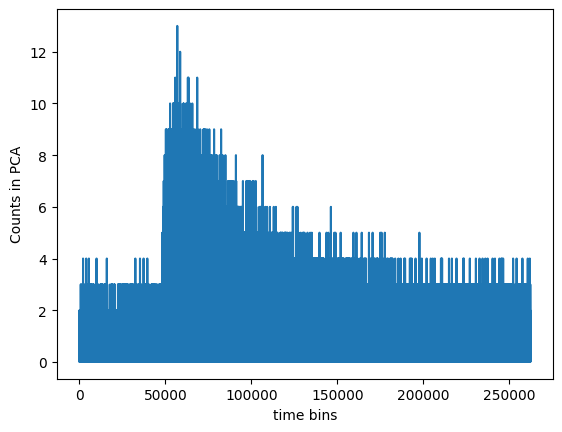

In [4]:
fig, ax = plt.subplots()
ax.plot(data)
ax.set_ylabel("Counts in PCA")
ax.set_xlabel("time bins")

In [5]:
binned_data = data.reshape(N // 256, 256).sum(axis=1)
T = 32
times = np.linspace(0, T, len(binned_data), endpoint=False)

Text(0, 0.5, 'counts in PCA')

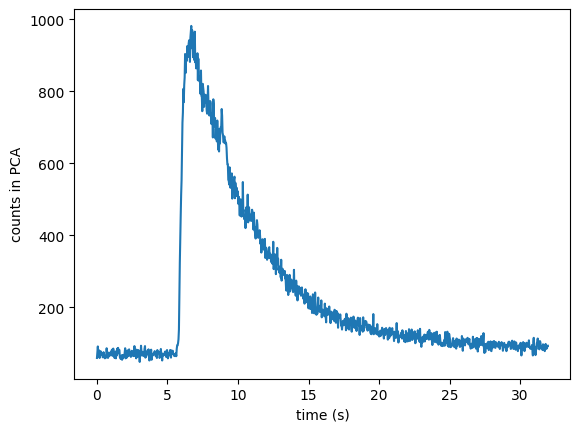

In [6]:
fig, ax = plt.subplots()
ax.plot(times, binned_data)
ax.set_xlabel("time (s)")
ax.set_ylabel("counts in PCA")

### **With your larger group, try to answer the following**:

1. What does counts in PCA mean in the y-axis of our plots?

> Your groups response here. 

2. In such systems, _how_ does the burst occur? What takes place prior to the _burst_ in the binary?

> Your groups response here. 

## b. -Fast-Fourier Transform of the Data


### **Individually/with the person next to you**:

Using the **raw flattened data (non-binned)**, 


1. compute a one-dimensional discrete [Fourier Transform using numpy `np.fft.rfft`](https://numpy.org/doc/2.2/reference/generated/numpy.fft.rfft.html) to obtain the Fourier coefficients $C_{k}$.

2. Next, compute the physical frequencies using [numpy.fft.rfftfreq](https://numpy.org/doc/2.1/reference/generated/numpy.fft.rfftfreq.html). 

```{tip}
NumPy's `rfftfreq` can take the sampling rate to return physical frequencies
```

> Hint: You will need to pass the total number of samples from earlier `N` then multiply by $N/T$ where $T=32$ s and is the total duration of the signal. 

3. Using $C_{k}$ and `kreq` plot the power spectrum as a function of frequency: (`kfreq`,`np.abs(c_k)**2 * 2 / N`) using log-log. 

>Hint: Here we see a signal around 300 Hz. We'll bin the Fourier data to increase the signal to noise.  The original paper did this by a factor of 8.

4. Bin the data using the provided lines and Replot using a log-log plot. 

5. Lastly, replot separately the binned FFT data with the following limits:
    * ax.set_xlim(340, 380)
    * ax.set_ylim(0, 20)
    
  

In [7]:
# 1 here
c_k = np.fft.rfft(data)

In [8]:
rate = T / N
kfreq = np.fft.rfftfreq(N, d=rate)

Text(0.5, 1.0, 'FFT of raw X ray Burst 4U 1728-34 data')

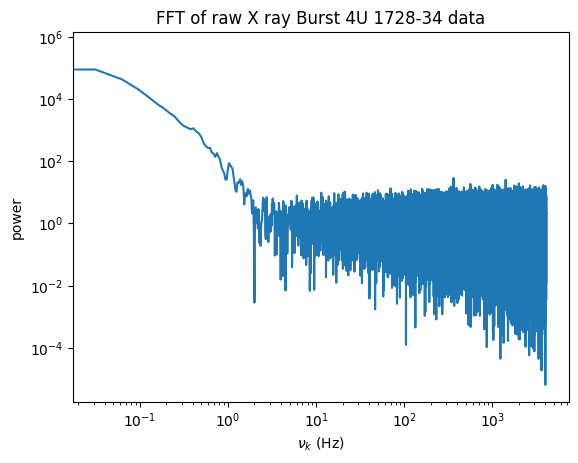

In [9]:
fig, ax = plt.subplots()
ax.plot(kfreq, np.abs(c_k)**2 * 2 / N)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"$\nu_k~(\rm{Hz})$")
ax.set_ylabel("power")
ax.set_title('FFT of raw X ray Burst 4U 1728-34 data')

In [10]:
c_k_binned = np.abs(c_k[1:]).reshape(int(len(c_k)//8), 8).mean(axis=1)
kfreq_binned = kfreq[1:].reshape(int(len(kfreq)//8), 8).mean(axis=1)

Text(0.5, 1.0, 'FFT of binned X ray Burst 4U 1728-34 data')

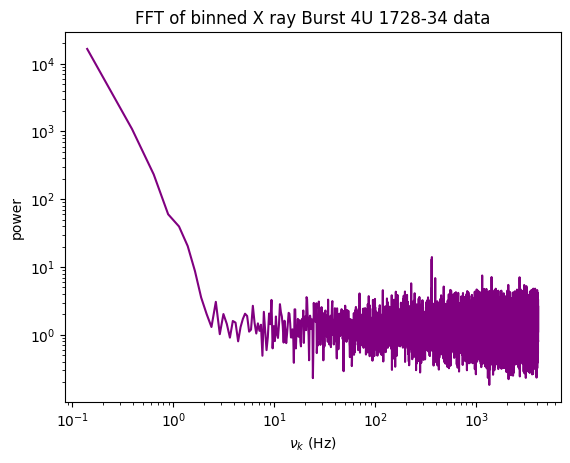

In [11]:
fig, ax = plt.subplots()
ax.plot(kfreq_binned, c_k_binned**2 * 2 / N,color='purple')
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\nu_k~(\rm{Hz})$")
ax.set_ylabel("power")
ax.set_title('FFT of binned X ray Burst 4U 1728-34 data')

(0.0, 20.0)

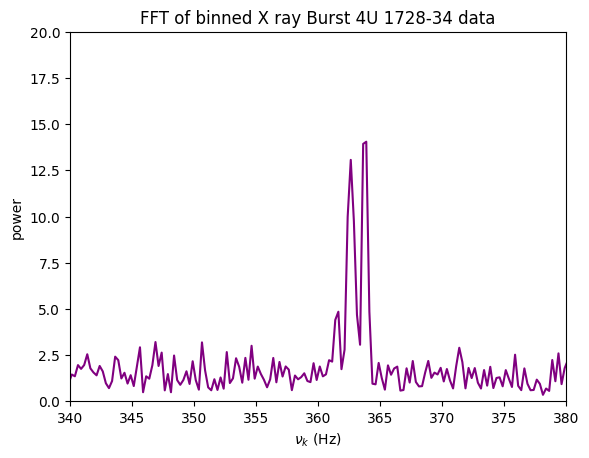

In [12]:
fig, ax = plt.subplots()
ax.plot(kfreq_binned, c_k_binned**2 * 2 / N,color='purple')
ax.set_xlabel(r"$\nu_k~(\rm{Hz})$")
ax.set_ylabel("power")
ax.set_title('FFT of binned X ray Burst 4U 1728-34 data')

ax.set_xlim(340, 380)
ax.set_ylim(0, 20)

### **With your larger group, try to answer the following**:

1. What does it mean to take a [Fast Fourier transform](https://en.wikipedia.org/wiki/Fast_Fourier_transform) of observational time series data, what might we learn from the FFT?

> Your groups response here. 

2. Did your group identify a frequency of significance? That had an excess of power in comparison to the others?

> Hint: Ignore the low frequency signal (< 1 Hz) in this case. 

> Your groups response here. 

3. What _physically_ could this recurring signal correspond to about the binary star system?

> Your groups response here. 

4. Using the approximate frequency obtained from the plots, compute the period $P=1/f$ (s) of this data.

> Your groups response here. 

```{toggle}
This shows a clear peak around 363 Hz, matching the inset in Figure 1 of Strohmayer et al. 1996.
This was identified as the rotation rate of the neutron star and the first significant evidence of a millisecond pulsar rotational speeds.
```